/tmp/ipython-input-116476349.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.groupby(pd.Grouper(key='OrderDate', freq='M'))['SalesAmount'].sum().reset_index()
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmptescxrtw/ek60agc1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptescxrtw/3wndrnu0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=66235', 'data', 'file=/tmp/tmptescxrtw/ek60agc1.json', 'init=/tmp/tmptescxrtw/3wndrnu0.json', 'output', 'file=/tmp/tmptescxrtw/prophet_modelt5tgtjvu/prophet_model-20251027160204.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
16:

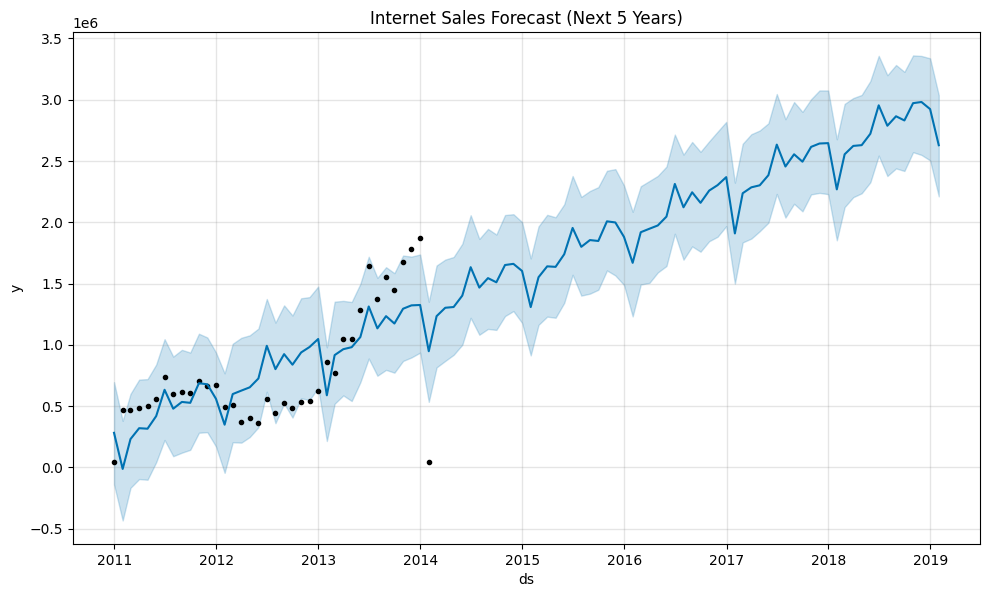

=== Product with highest total sales ===
ProductKey
312    1205876.99
Name: SalesAmount, dtype: float64

Files saved: monthly_sales_prepared.csv, forecast_results.csv, product_sales_summary.csv


In [1]:
# ===============================
# 1) Import libraries
# ===============================
import pandas as pd
import matplotlib.pyplot as plt


!pip install prophet
from prophet import Prophet

# ===============================
# 2) Load data
# ===============================
df = pd.read_csv("InternetSales.csv", encoding="latin1", low_memory=False)


df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# ===============================
# 3) Monthly sales aggregation
# ===============================
monthly = df.groupby(pd.Grouper(key='OrderDate', freq='M'))['SalesAmount'].sum().reset_index()
monthly.columns = ['ds', 'y']   # Prophet 要求列名必须为 ds 和 y

# ===============================
# 4) Fit Prophet model & forecast 60 months
# ===============================
m = Prophet()
m.fit(monthly)

future = m.make_future_dataframe(periods=60, freq='M')
forecast = m.predict(future)

# ===============================
# 5) Plot forecast
# ===============================
fig1 = m.plot(forecast)
plt.title("Internet Sales Forecast (Next 5 Years)")
plt.show()

# ===============================
# 6) Summary statistics: which product generates the most sales
# ===============================
product_sales = df.groupby('ProductKey')['SalesAmount'].sum().sort_values(ascending=False)
top_product = product_sales.head(1)

print("=== Product with highest total sales ===")
print(top_product)

# ===============================
# 7) Save outputs (for upload to Canvas / GitHub)
# ===============================
monthly.to_csv("monthly_sales_prepared.csv", index=False)
forecast.to_csv("forecast_results.csv", index=False)
product_sales.to_csv("product_sales_summary.csv")

print("\nFiles saved: monthly_sales_prepared.csv, forecast_results.csv, product_sales_summary.csv")
